In [1]:
import numpy as np
from PIL import Image
import cv2
# from scipy.ndimage import gaussian_filter
import tensorflow as tf
# from sklearn.model_selection import train_test_split

In [2]:
TARGET_SIZE = (256, 256)

In [3]:
def preprocess_images(images, target_size=TARGET_SIZE):
    resized = []
    for img in images:
        pil_img = Image.fromarray(
            np.uint8(img) if img.dtype != np.uint8 else img
        ).convert("RGB")
        resized.append(
            np.array(pil_img.resize(target_size[::-1], Image.BILINEAR), dtype=np.float32)
        )
    result = np.stack(resized, axis=0)
    return result / 255.0 if result.max() > 1.0 else result


def preprocess_masks(masks, target_size=TARGET_SIZE):
    resized = []
    for mask in masks:
        m_float = mask.astype(np.float32)
        if m_float.max() > 1.0:
            m_float /= 255.0
        pil_mask = Image.fromarray(m_float, mode="F").resize(
            target_size[::-1], Image.BILINEAR
        )
        resized.append(np.array(pil_mask, dtype=np.float32))
    result = (np.stack(resized, axis=0) >= 0.5).astype(np.float32)
    return result[..., np.newaxis]


# X = preprocess_images(images)
# Y = preprocess_masks(masks)

# train_images, val_images, train_masks, val_masks = train_test_split(
#     X, Y, test_size=0.2, random_state=42
# )
# print(f"Train: {len(train_images)}, Val: {len(val_images)}")


# ── 3. Data augmentation via tf.data ─────────────────────────────────────────
def augment(image, mask):
    """Apply random augmentations to an image-mask pair (same transforms)."""
    # Random horizontal flip
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    # Random brightness/contrast on image only
    image = tf.image.random_brightness(image, 0.15)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.clip_by_value(image, 0.0, 1.0)

    # Random rotation (small angles via affine)
    angle = tf.random.uniform((), -15.0, 15.0) * (np.pi / 180.0)
    image = _rotate_tensor(image, angle)
    mask = _rotate_tensor(mask, angle)

    # Re-binarize mask after rotation interpolation
    mask = tf.cast(mask >= 0.5, tf.float32)
    return image, mask


def _rotate_tensor(tensor, angle):
    """Rotate a 3D tensor (H, W, C) by angle radians."""
    cos_a = tf.cos(angle)
    sin_a = tf.sin(angle)
    # Affine transform expects [a0 a1 a2 b0 b1 b2 c0 c1] for projective
    h = tf.cast(tf.shape(tensor)[0], tf.float32)
    w = tf.cast(tf.shape(tensor)[1], tf.float32)
    cx, cy = w / 2.0, h / 2.0
    transform = [
        cos_a, -sin_a, cx - cx * cos_a + cy * sin_a,
        sin_a, cos_a, cy - cx * sin_a - cy * cos_a,
        0.0, 0.0,
    ]
    tensor = tf.expand_dims(tensor, 0)
    tensor = tf.raw_ops.ImageProjectiveTransformV3(
        images=tensor,
        transforms=tf.reshape(transform, [1, 8]),
        output_shape=tf.shape(tensor)[1:3],
        interpolation="BILINEAR",
        fill_mode="NEAREST",
        fill_value=0.0,
    )
    return tf.squeeze(tensor, 0)


In [4]:
import pickle

In [5]:
BATCH_SIZE = 8
AUTOTUNE = tf.data.AUTOTUNE

train_ds=tf.data.Dataset.load('/content/drive/MyDrive/train_dataset')
val_ds=tf.data.Dataset.load('/content/drive/MyDrive/val_dataset')

In [6]:
# ── 4. Loss functions ───────────────────────────────────────────────────────
def dice_coefficient(y_true, y_pred, smooth=1.0):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )


def bce_dice_loss(y_true, y_pred):
    """Combined Binary Cross-Entropy + Dice Loss for stable training."""
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    bce = tf.reduce_mean(bce)
    dice = 1.0 - dice_coefficient(y_true, y_pred)
    return bce + dice

In [7]:
# ── 5. Improved U-Net with BatchNorm + Dropout ──────────────────────────────
def build_unet(input_shape=(256, 256, 3)):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape, include_top=False, weights="imagenet"
    )

    skip_layer_names = [
        "block_1_expand_relu",   # 128x128
        "block_3_expand_relu",   # 64x64
        "block_6_expand_relu",   # 32x32
        "block_13_expand_relu",  # 16x16
    ]
    skips = [base_model.get_layer(name).output for name in skip_layer_names]
    x = base_model.output

    # Decoder with BatchNorm and Dropout
    for filters, skip in zip([512, 256, 128, 64], reversed(skips)):
        x = tf.keras.layers.UpSampling2D((2, 2))(x)
        x = tf.keras.layers.Concatenate()([x, skip])
        x = tf.keras.layers.Conv2D(filters, (3, 3), padding="same", use_bias=False)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation("relu")(x)
        x = tf.keras.layers.Conv2D(filters, (3, 3), padding="same", use_bias=False)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation("relu")(x)
        x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.UpSampling2D((2, 2))(x)
    x = tf.keras.layers.Conv2D(32, (3, 3), padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    outputs = tf.keras.layers.Conv2D(1, (1, 1), activation="sigmoid")(x)

    return tf.keras.Model(inputs=base_model.input, outputs=outputs)


In [8]:
model = build_unet()

# ── Phase 1: Freeze encoder, train decoder only ─────────────────────────────
print("\n=== Phase 1: Training decoder (encoder frozen) ===")
for layer in model.layers:
    if layer.name.startswith("block_") or layer.name.startswith("Conv1") or layer.name.startswith("expanded_conv"):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=bce_dice_loss,
    metrics=[dice_coefficient],
)

phase1_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_dice_coefficient", patience=10, restore_best_weights=True, mode="max"
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_dice_coefficient", factor=0.5, patience=3, min_lr=1e-5, mode="max", verbose=1
    ),
]

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=phase1_callbacks,
)

/tmp/ipykernel_5975/94602044.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

=== Phase 1: Training decoder (encoder frozen) ===
Epoch 1/30
441/441 ━━━━━━━━━━━━━━━━━━━━ 241s 398ms/step - dice_coefficient: 0.6104 - loss: 0.5411 - val_dice_coefficient: 0.7103 - val_loss: 0.4793 - learning_rate: 0.0010
Epoch 2/30
441/441 ━━━━━━━━━━━━━━━━━━━━ 89s 202ms/step - dice_coefficient: 0.7370 - loss: 0.3746 - val_dice_coefficient: 0.7376 - val_loss: 0.3970 - learning_rate: 0.0010
Epoch 3/30
441/441 ━━━━━━━━━━━━━━━━━━━━ 89s 200ms/step - dice_coefficient: 0.7821 - loss: 0.3129 - val_dice_coefficient: 0.7508 - val_loss: 0.3815 - learning_rate: 0.0010
Epoch 4/30
441/441 ━━━━━━━━━━━━━━━━━━━━ 89s 201ms/step - dice_coefficient: 0.8130 - loss: 0.2677 - val_dice_coefficient: 0.7523 - val_loss: 0.4045 - learning_rate: 0.0010
Epoch 5/30
441/441 ━━━━━━━━━━━━━━━━━━━━ 88s 200ms/step - dice_coefficient: 0.8343 - loss: 0.2366 - val_dice_coefficient: 0.7634 - val_loss: 0.3780 - learning_rate: 0.0010
Epoch 6/30
441/441 ━━━━━━━━━━━━━━━━━━━━ 89s

In [12]:
len(train_ds)

441

In [13]:
# ── Phase 2: Unfreeze encoder, fine-tune everything with low LR ─────────────
print("\n=== Phase 2: Fine-tuning entire model ===")
for layer in model.layers:
    layer.trainable = True

# Use cosine decay for smooth convergence
total_steps = len(train_ds) // BATCH_SIZE * 50
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4,
    decay_steps=total_steps,
    alpha=1e-6,
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(lr_schedule),
    loss=bce_dice_loss,
    metrics=[dice_coefficient],
)

phase2_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_face_model.weights.h5",
        monitor="val_dice_coefficient",
        save_best_only=True,
        mode="max",
        save_weights_only=True,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_dice_coefficient", patience=20, restore_best_weights=True, mode="max"
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=phase2_callbacks,
)

# ── 7. Save ─────────────────────────────────────────────────────────────────
model.save("face_segmentation_model.keras")
print("Training complete. Model saved as face_segmentation_model.keras")

# Print final metrics
val_loss, val_dice = model.evaluate(val_ds, verbose=0)
print(f"Final validation Dice: {val_dice:.4f}")



=== Phase 2: Fine-tuning entire model ===
Epoch 1/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 229s 352ms/step - dice_coefficient: 0.8126 - loss: 0.3063 - val_dice_coefficient: 0.7829 - val_loss: 0.3386
Epoch 2/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 101s 229ms/step - dice_coefficient: 0.8821 - loss: 0.1689 - val_dice_coefficient: 0.7922 - val_loss: 0.3393
Epoch 3/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 101s 228ms/step - dice_coefficient: 0.9166 - loss: 0.1176 - val_dice_coefficient: 0.7923 - val_loss: 0.3496
Epoch 4/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 101s 228ms/step - dice_coefficient: 0.9350 - loss: 0.0907 - val_dice_coefficient: 0.7925 - val_loss: 0.3601
Epoch 5/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 101s 229ms/step - dice_coefficient: 0.9456 - loss: 0.0750 - val_dice_coefficient: 0.7941 - val_loss: 0.3634
Epoch 6/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 100s 225ms/step - dice_coefficient: 0.9516 - loss: 0.0663 - val_dice_coefficient: 0.7938 - val_loss: 0.3661
Epoch 7/50
441/441 ━━━━━━━━━━━━━━━━━━━━ 99s 225ms/step - dice_coeffic

In [15]:
import numpy as np
import time
import pandas as pd
import tensorflow as tf

def perform_final_evaluation(model, dataset):
    """
    Evaluates the model using a tf.data.Dataset object.
    Targets: Dice > 0.92, IoU > 0.88, F1 > 0.90, Inference < 100ms.
    """
    dice_scores = []
    iou_scores = []
    f1_scores = []
    inference_times = []

    print("Starting evaluation on dataset...")

    # Iterate through the tf.data.Dataset
    # Note: images and masks will arrive in batches based on your BATCH_SIZE (8)
    for images, masks in dataset:

        # 1. Measure Inference Speed
        # We time the entire batch and divide by batch size for an average per-sample time
        start_time = time.perf_counter()
        preds = model.predict(images, verbose=0)
        end_time = time.perf_counter()

        # Calculate average time per sample in this batch (in milliseconds)
        batch_size = tf.shape(images)[0].numpy()
        avg_inference_time = ((end_time - start_time) * 1000.0) / batch_size

        # We append the average for this batch for each sample in the batch
        for _ in range(batch_size):
            inference_times.append(avg_inference_time)

        # 2. Process Metrics for each item in the batch
        # Convert tensors to numpy for the metric logic
        preds_np = preds
        masks_np = masks.numpy()

        for i in range(batch_size):
            sample_mask_true = masks_np[i].flatten()
            # Binarize prediction
            y_pred = (preds_np[i].flatten() >= 0.5).astype(np.float32)

            # 3. Calculate Metrics
            intersection = np.sum(sample_mask_true * y_pred)
            sum_true = np.sum(sample_mask_true)
            sum_pred = np.sum(y_pred)
            union = sum_true + sum_pred - intersection

            # Dice Coefficient
            dice = (2.0 * intersection + 1e-7) / (sum_true + sum_pred + 1e-7)
            # IoU
            iou = (intersection + 1e-7) / (union + 1e-7)
            # F1-Score
            precision = (intersection + 1e-7) / (sum_pred + 1e-7)
            recall = (intersection + 1e-7) / (sum_true + 1e-7)
            f1 = (2 * precision * recall) / (precision + recall + 1e-7)

            dice_scores.append(dice)
            iou_scores.append(iou)
            f1_scores.append(f1)

    # Aggregate Results
    metrics_summary = {
        'Metric': ['Dice Coefficient', 'IoU', 'F1-Score', 'Avg Inference Time'],
        'Actual': [
            np.mean(dice_scores),
            np.mean(iou_scores),
            np.mean(f1_scores),
            np.mean(inference_times)
        ],
        'Target': ['> 0.92', '> 0.88', '> 0.90', '< 100ms']
    }

    df = pd.DataFrame(metrics_summary)
    df['Pass'] = [
        '✅' if df.loc[0, 'Actual'] > 0.92 else '❌',
        '✅' if df.loc[1, 'Actual'] > 0.88 else '❌',
        '✅' if df.loc[2, 'Actual'] > 0.90 else '❌',
        '✅' if df.loc[3, 'Actual'] < 100.0 else '❌'
    ]

    print("\n" + "="*50)
    print("FINAL EVALUATION MATRIX (TF.DATA)")
    print("="*50)
    # Custom formatting for the printout
    for i, row in df.iterrows():
        val = f"{row['Actual']:.4f}" if i < 3 else f"{row['Actual']:.2f}ms"
        print(f"{row['Metric']:20} | {val:10} | Target: {row['Target']:8} | {row['Pass']}")
    print("="*50)

    return df

# Usage
# Pass your existing val_ds object here
results_df = perform_final_evaluation(model, val_ds)

Starting evaluation on dataset...

FINAL EVALUATION MATRIX (TF.DATA)
Dice Coefficient     | 0.7424     | Target: > 0.92   | ❌
IoU                  | 0.6339     | Target: > 0.88   | ❌
F1-Score             | 0.7424     | Target: > 0.90   | ❌
Avg Inference Time   | 35.77ms    | Target: < 100ms  | ✅


In [16]:
import matplotlib.pyplot as plt
from PIL import Image
def predict_local_image(image_path):
    # 2. Load and Preprocess the image
    raw_img = Image.open(image_path).convert("RGB")
    # Resize to the target size used in training (256x256) [cite: 9, 12]
    img_resized = raw_img.resize((256, 256), Image.BILINEAR)
    img_array = np.array(img_resized).astype(np.float32)

    # Normalize pixel values to [0, 1] [cite: 9, 13]
    img_tensor = img_array / 255.0
    # Add batch dimension: (1, 256, 256, 3) [cite: 68, 74]
    img_tensor = np.expand_dims(img_tensor, axis=0)

    # 3. Perform Inference
    prediction = model.predict(img_tensor, verbose=0)[0]

    # 4. Binarize the mask at 0.5 threshold [cite: 9, 75]
    mask = (prediction >= 0.5).astype(np.uint8)

    # 5. Visualization
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img_resized)
    ax[0].set_title("Downloaded Image")
    ax[0].axis('off')

    ax[1].imshow(mask[:, :, 0], cmap='gray')
    ax[1].set_title("Predicted Face Mask")
    ax[1].axis('off')
    plt.show()

# Example usage:
# predict_local_image('my_downloaded_face.jpg')

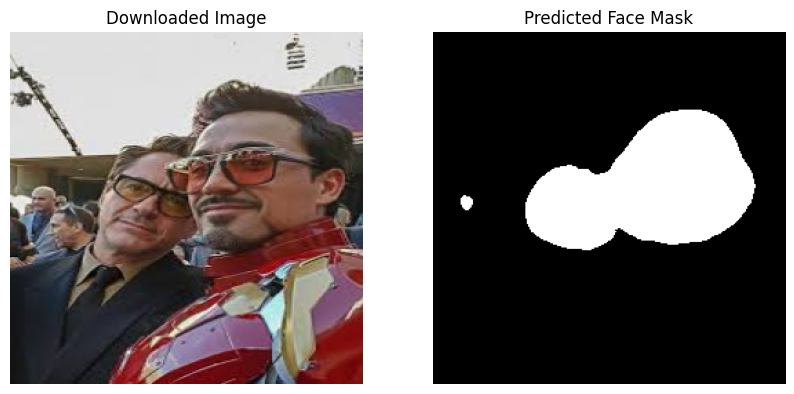

In [17]:
predict_local_image('/content/drive/MyDrive/images.jpg')

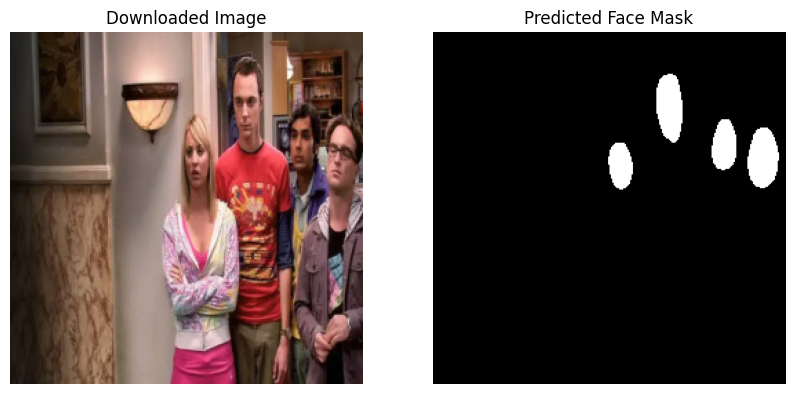

In [19]:
predict_local_image('/content/drive/MyDrive/bingbang.webp')

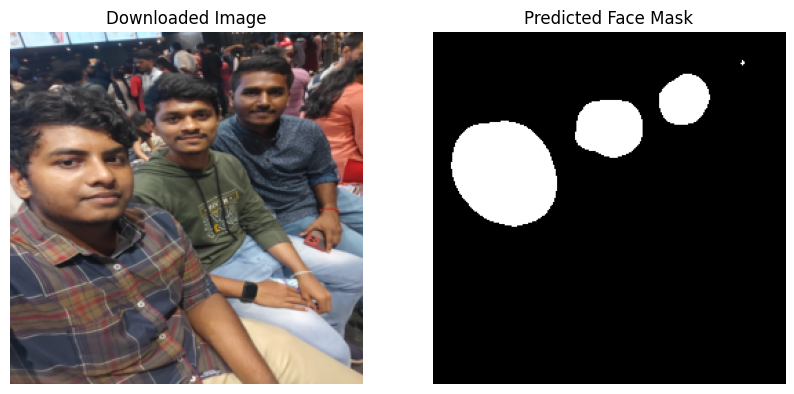

In [20]:
predict_local_image('/content/drive/MyDrive/Group photo/1682952359153.jpg')

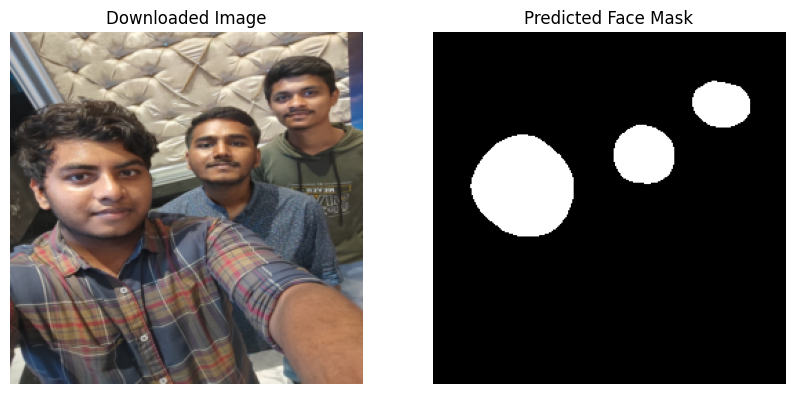

In [21]:
predict_local_image('/content/drive/MyDrive/Group photo/1682952359159.jpg')

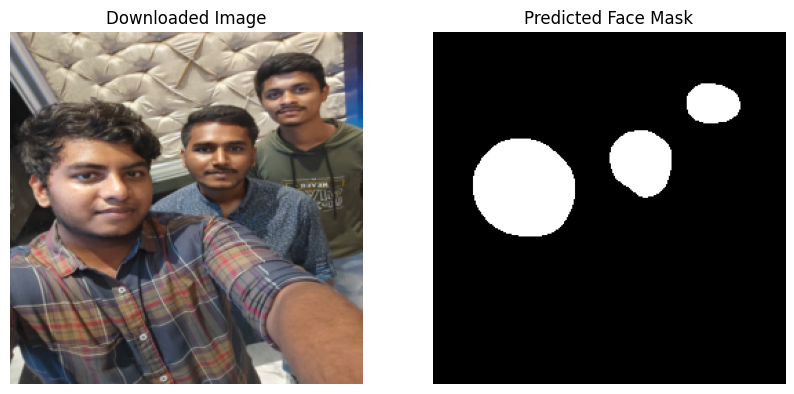

In [22]:
predict_local_image('/content/drive/MyDrive/Group photo/1682952359165.jpg')

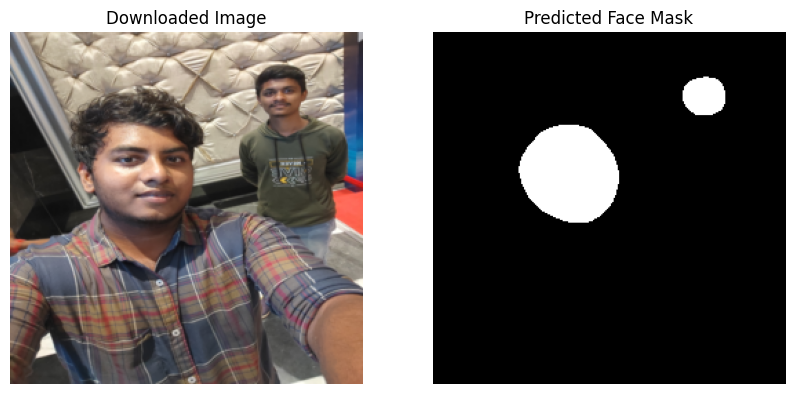

In [23]:
predict_local_image('/content/drive/MyDrive/Group photo/1682952359171.jpg')

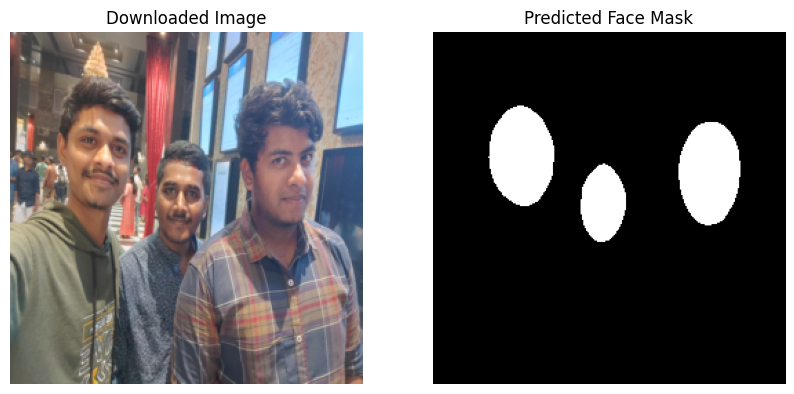

In [24]:
predict_local_image('/content/drive/MyDrive/Group photo/1682952359176.jpg')

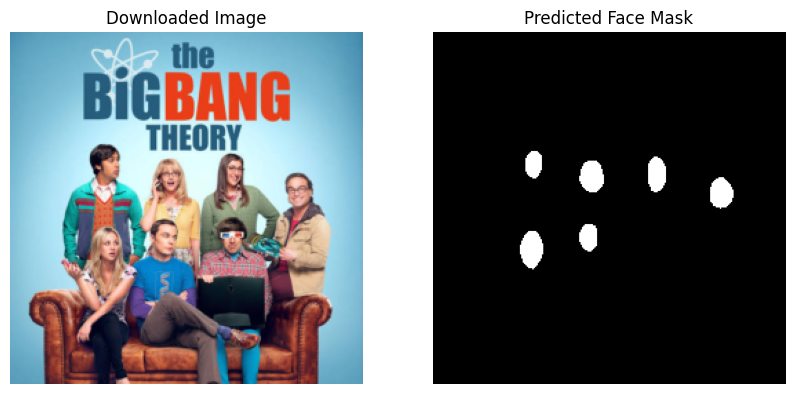

In [25]:
predict_local_image('/content/drive/MyDrive/images (1).jpg')

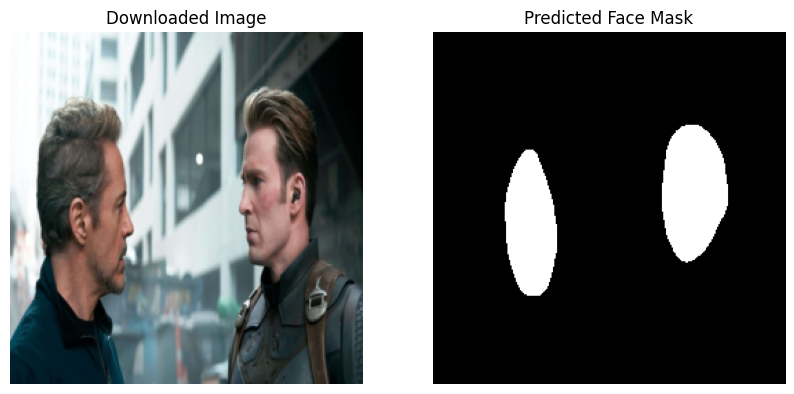

In [26]:
predict_local_image('/content/drive/MyDrive/image 2.jpg')

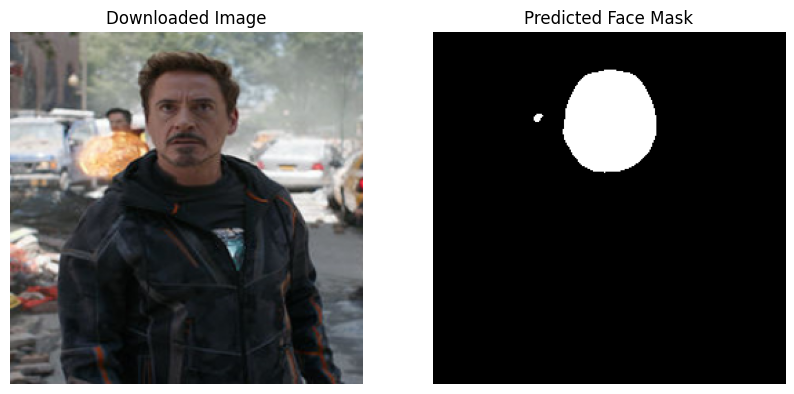

In [27]:
predict_local_image('/content/drive/MyDrive/image 3.jpg')